<a href="https://colab.research.google.com/github/Loopinlogix/Unsupervised_Image_Classification_and_Visualization/blob/main/US_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Unsupervised Image Clustering and Visualization
#About this project:


In [3]:
#GITHUB


# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/Unsupervised_Image_Classification_and_Visualization.git

# Change directory into the cloned repository
%cd Unsupervised_Image_Classification_and_Visualization

# List the contents of the directory
!ls

Cloning into 'Unsupervised_Image_Classification_and_Visualization'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Unsupervised_Image_Classification_and_Visualization/Unsupervised_Image_Classification_and_Visualization
README.md


STEP 1: Import Libraries
Libraries imported successfully.
STEP 2: Load Dataset - Olivetti Faces
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 64, 64) (400, 4096)
Images shape: (400, 64, 64)
Flattened shape: (400, 4096)
Pixel range: 0.0 to 1.0
STEP 3: EDA - VISUALIZE RANDOM FACES


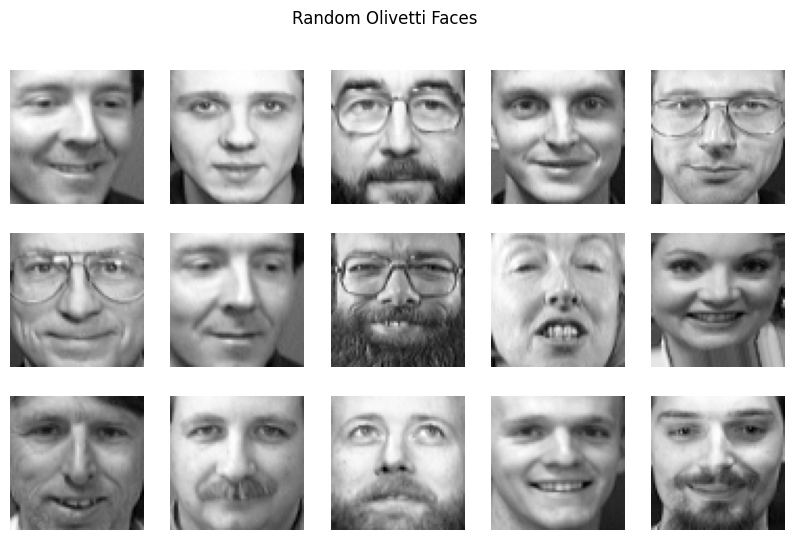

STEP 4: PIXEL INTENSITY DISTRIBUTION


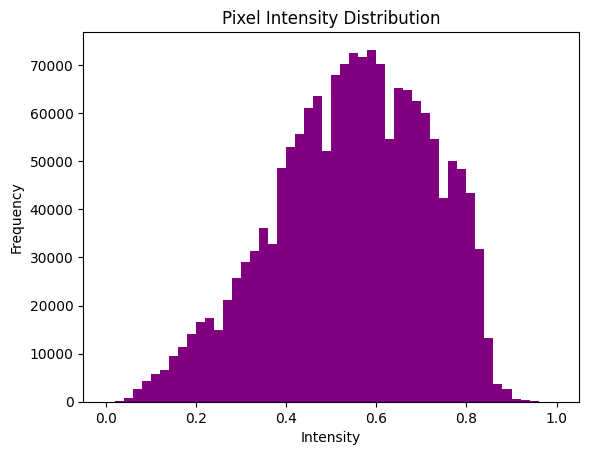

STEP 4: MEAN FACE


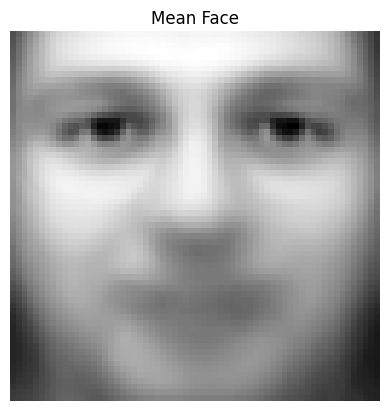

STEP 4: DISPLAYING OTHER FACES


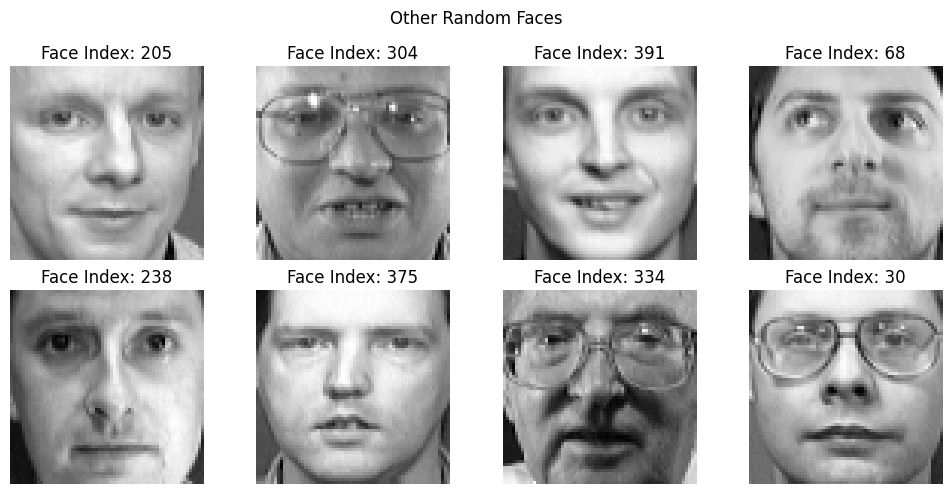

STEP 4: VARIAMCE HEATMAP


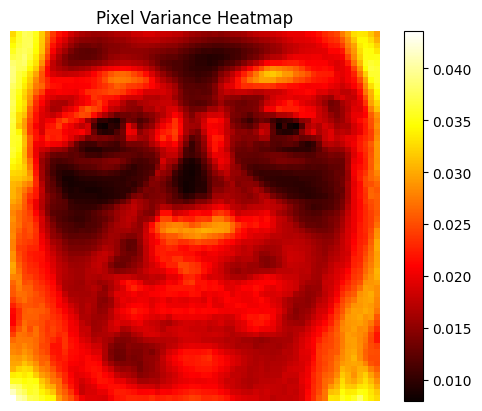

STEP 5: COSINE SIMILARITY


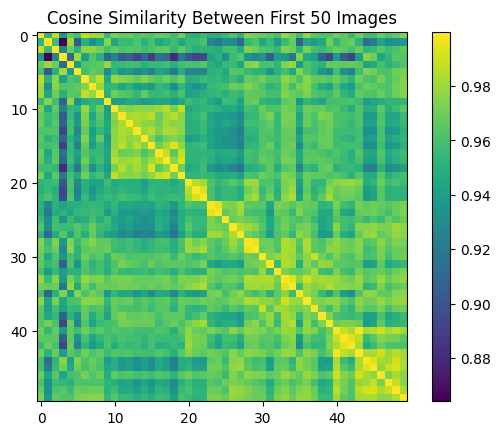

STEP 6: K-MEANS CLUSTERING
K-Means clustering performed successfully with n_clusters=40.
STEP 7: VISUALIZE K MEANS CLUSTERING


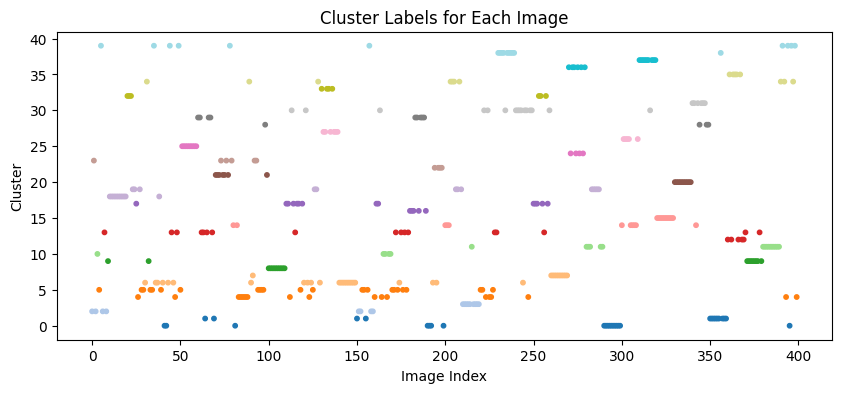

STEP 8: ELBOW METHOD TO FIND OPTIMAL K


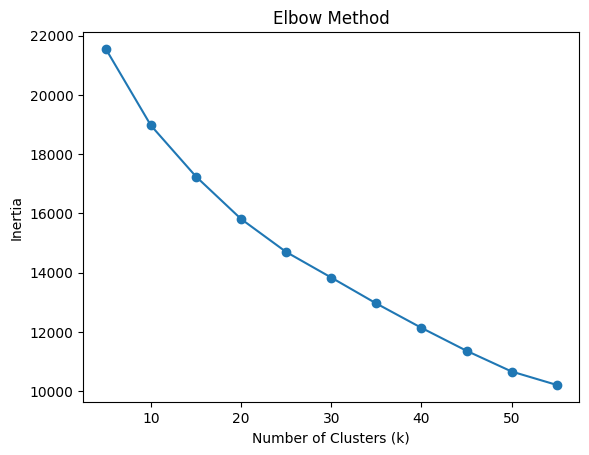

STEP 9: PREDICT CLUSTER FOR NEW IMAGES
Predicted cluster: [2]
STEP 9: MULTIPLE SAMPLES
Image 0 → Cluster 2
Image 1 → Cluster 23
Image 2 → Cluster 2
Image 3 → Cluster 10
Image 4 → Cluster 5
STEP 10: 5 SAMPLES PER CLUSTER


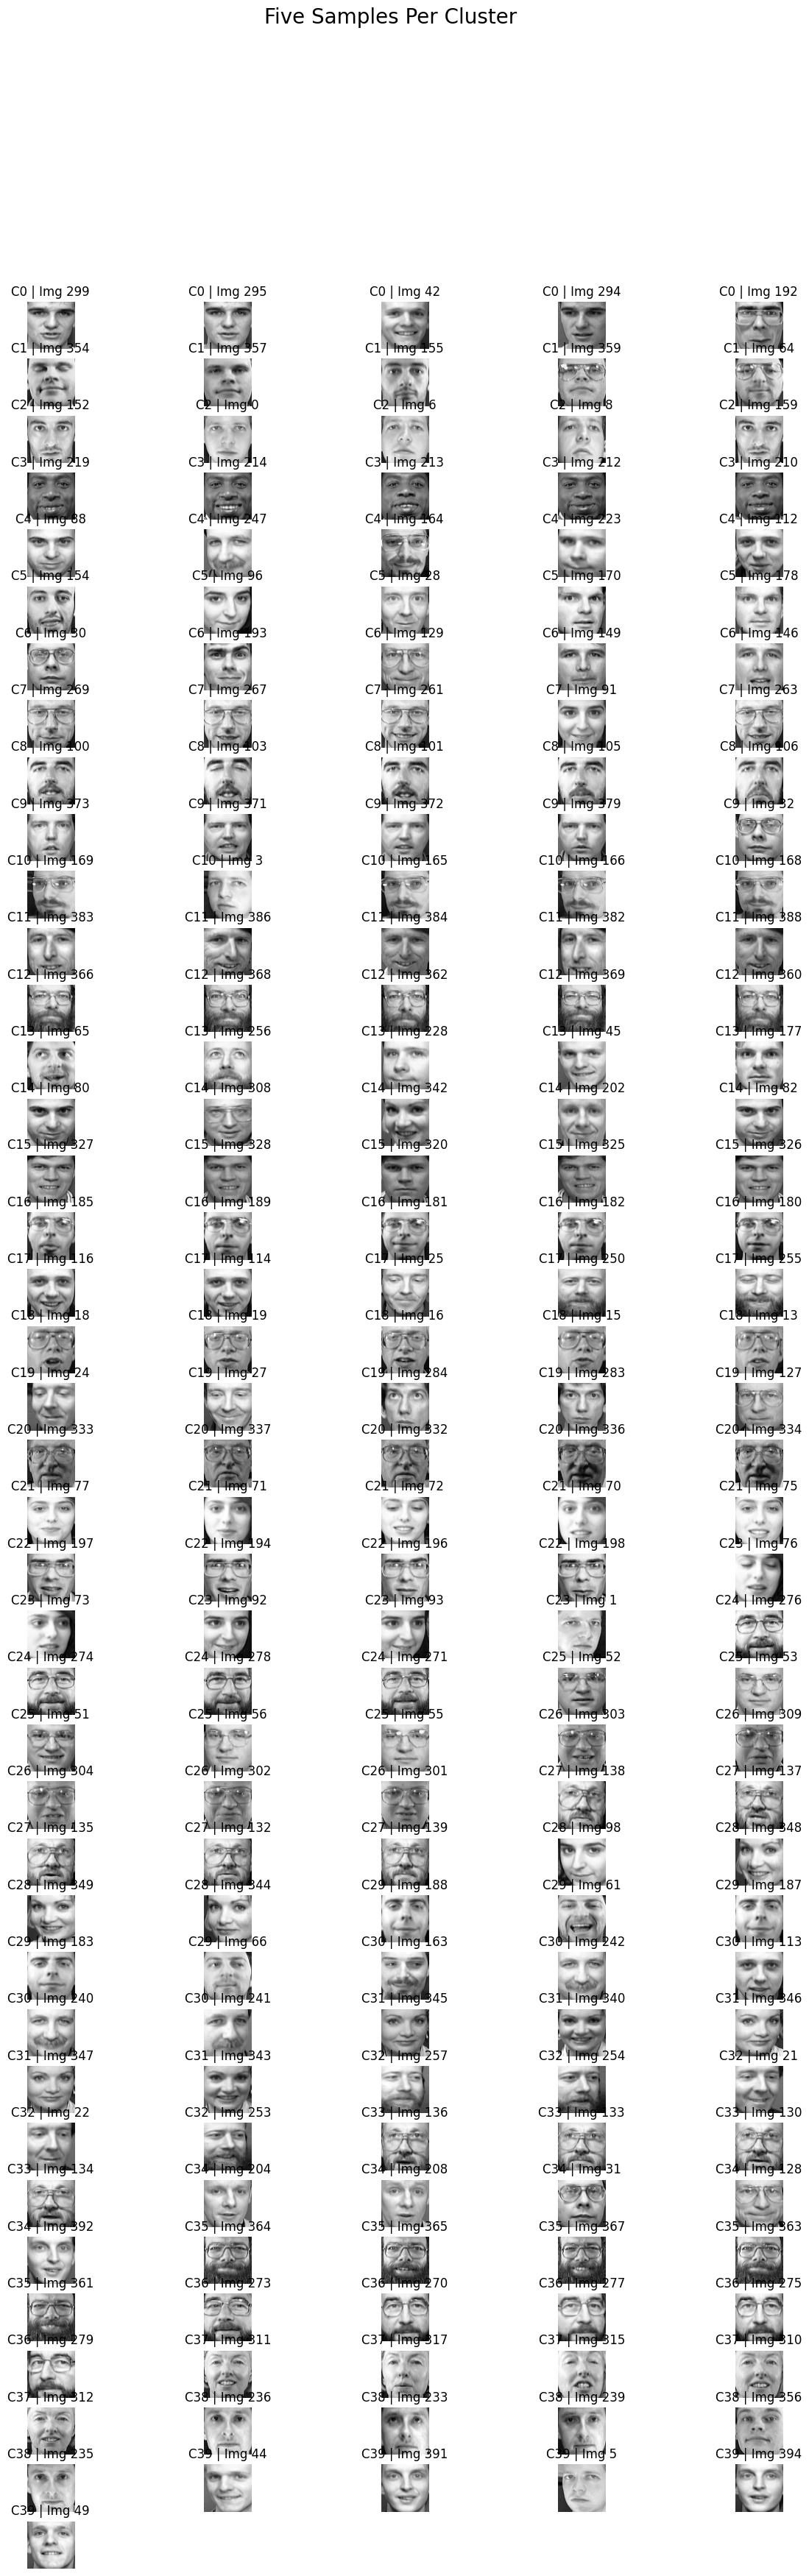

STEP 11: PCA to 50 Components (for t-SNE)
Shape of X_pca: (400, 50)
STEP 12: PCA 2D VISUALIZATION


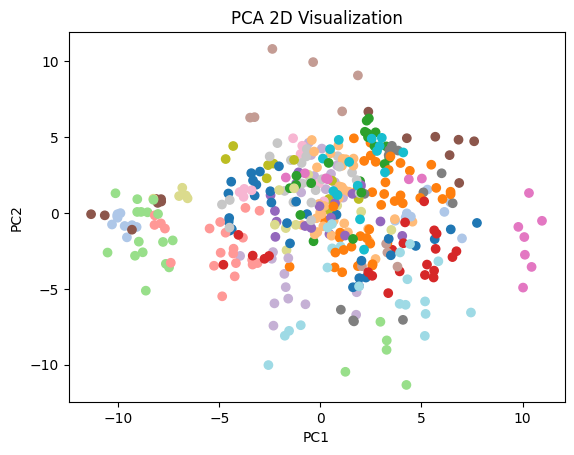

STEP 13: T-SNE VISUALIZATION


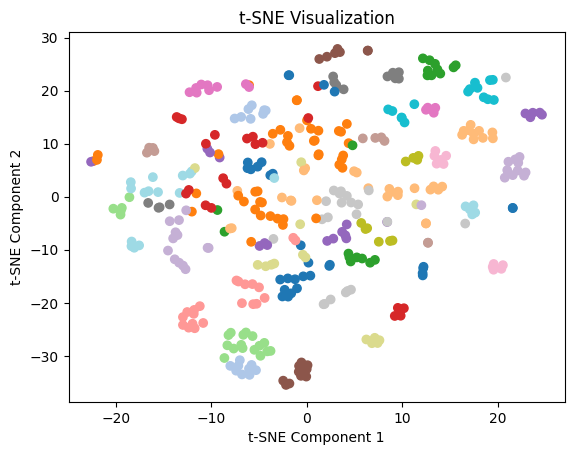

STEP 14: SPLIT DATA INTO TRAINING AND TEST SETS
Shape of X_train: (320, 4096)
Shape of X_test: (80, 4096)
Shape of labels_train: (320,)
Shape of labels_test: (80,)
STEP 15: RE-APPLY K-MEANS ON TRAINING DATA
K-Means model trained on X_train successfully.
Shape of kmeans_train_labels: (320,)
STEP 16: PREDICT CLUSTERS FOR TEST DATA
Shape of kmeans_test_labels: (80,)
Sample of predicted labels for X_test: [36  9 12 23 26 13 31  8 20  2]
STEP 17: ANALYZE AND VISUALIZE TEST PREDICTIONS (Sample Images)


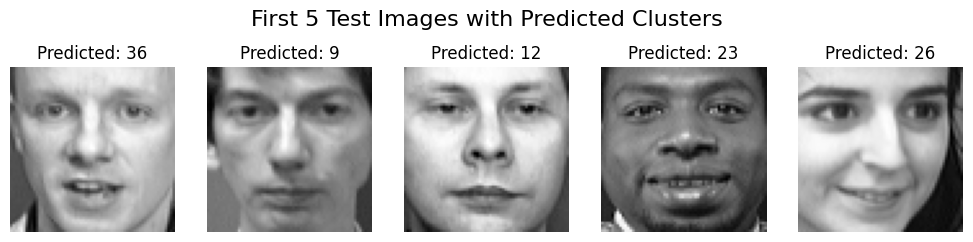

STEP 18: PCA 2D Visualization of Test Data with Predicted Clusters


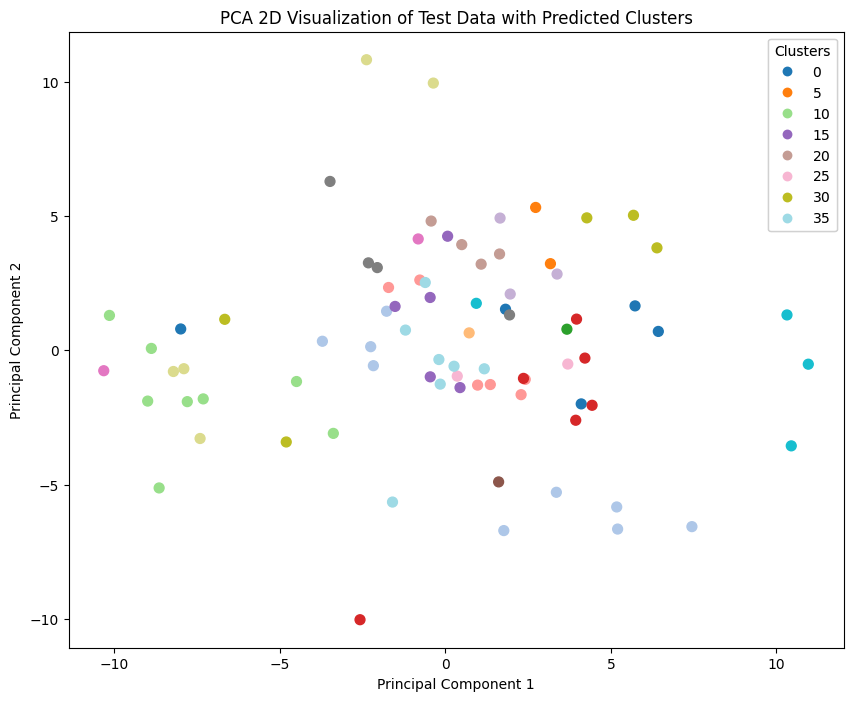

STEP 19: t-SNE Visualization of Test Data with Predicted Clusters


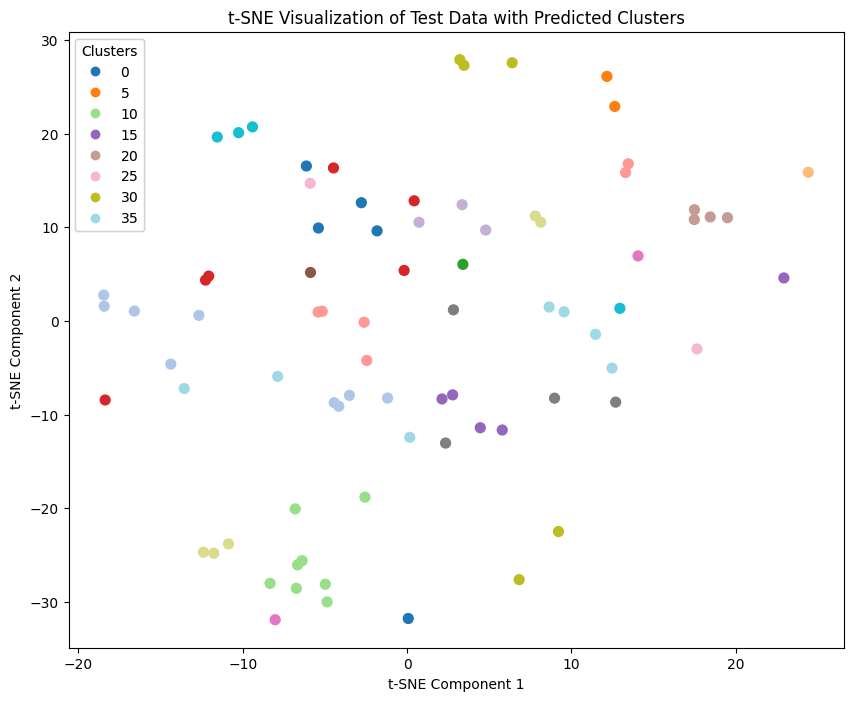

STEP 20: ANALYZE CLUSTER CENTROIDS


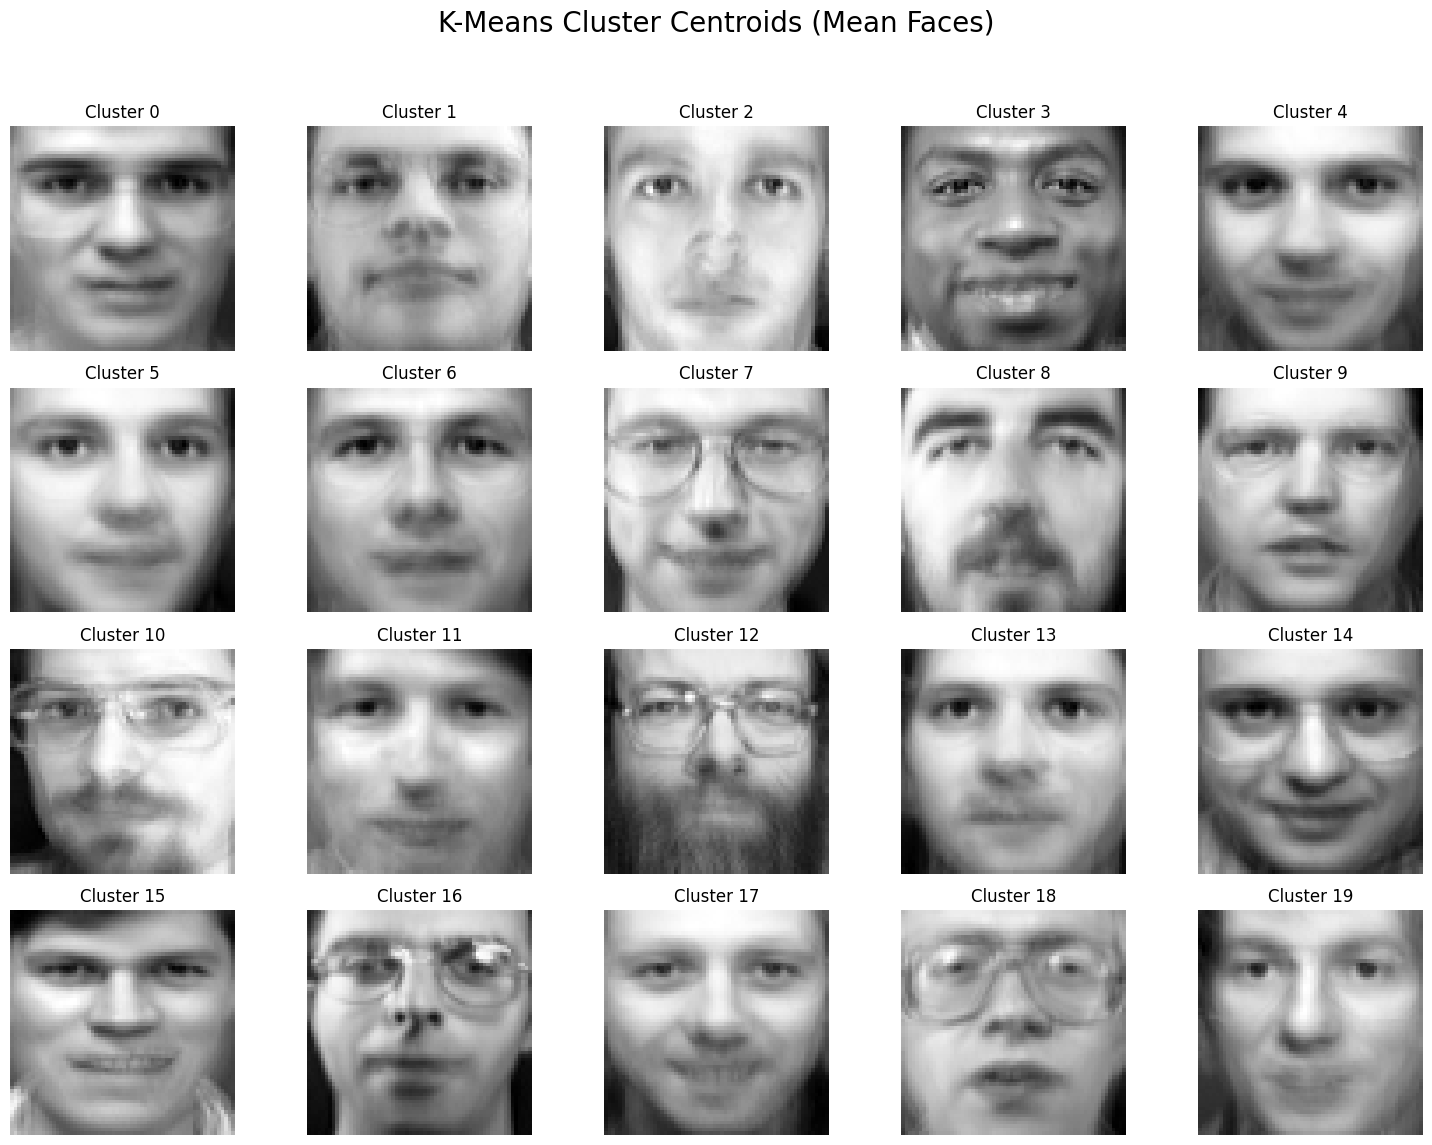

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

print("=" * 60)
print("STEP 1: Import Libraries")
print("=" * 60)
print("Libraries imported successfully.")

print("=" * 60)
print("STEP 2: Load Dataset - Olivetti Faces")
print("=" * 60)

data = fetch_olivetti_faces()
images = data.images          # shape: (400, 64, 64)
X = data.data                 # shape: (400, 4096)

#check shape
print(images.shape, X.shape)
print("Images shape:", images.shape)
print("Flattened shape:", X.shape)
print("Pixel range:", X.min(), "to", X.max())

print("=" * 60)
print("STEP 3: EDA - VISUALIZE RANDOM FACES")
print("=" * 60)

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax in axes.flat:
    idx = np.random.randint(0, 400)
    ax.imshow(images[idx], cmap='gray')
    ax.axis('off')
plt.suptitle("Random Olivetti Faces")
plt.show()

print("=" * 60)
print("STEP 4: PIXEL INTENSITY DISTRIBUTION")
print("=" * 60)

plt.hist(X.flatten(), bins=50, color='purple')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

print("=" * 60)
print("STEP 4: MEAN FACE")
print("=" * 60)

mean_face = X.mean(axis=0).reshape(64, 64)
plt.imshow(mean_face, cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()

print("=" * 60)
print("STEP 4: DISPLAYING OTHER FACES")
print("=" * 60)

# Display a few other random faces
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax in axes.flat:
    idx = np.random.randint(0, images.shape[0])  # Select a random index
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"Face Index: {idx}")
    ax.axis('off')
plt.suptitle("Other Random Faces")
plt.tight_layout()
plt.show()


print("=" * 60)
print("STEP 4: VARIAMCE HEATMAP")
print("=" * 60)
variance_face = X.var(axis=0).reshape(64, 64)
plt.imshow(variance_face, cmap='hot')
plt.title("Pixel Variance Heatmap")
plt.axis('off')
plt.colorbar()
plt.show()

print("=" * 60)
print("STEP 5: COSINE SIMILARITY")
print("=" * 60)
similarity_matrix = cosine_similarity(X[:50])
plt.imshow(similarity_matrix, cmap='viridis')
plt.title("Cosine Similarity Between First 50 Images")
plt.colorbar()
plt.show()

print("=" * 60)
print("STEP 6: K-MEANS CLUSTERING")
print("=" * 60)

kmeans = KMeans(n_clusters=40, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print("K-Means clustering performed successfully with n_clusters=40.")

print("=" * 60)
print("STEP 7: VISUALIZE K MEANS CLUSTERING")
print("=" * 60)
plt.figure(figsize=(10, 4))
plt.scatter(range(len(labels)), labels, s=10, c=labels, cmap='tab20')
plt.title("Cluster Labels for Each Image")
plt.xlabel("Image Index")
plt.ylabel("Cluster")
plt.show()


print("=" * 60)
print("STEP 8: ELBOW METHOD TO FIND OPTIMAL K")
print("=" * 60)
inertias = []
K = range(5, 60, 5)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


print("=" * 60)
print("STEP 9: PREDICT CLUSTER FOR NEW IMAGES")
print("=" * 60)
sample = X[0].reshape(1, -1)
pred_cluster = kmeans.predict(sample)
print("Predicted cluster:", pred_cluster)

print("=" * 60)
print("STEP 9: MULTIPLE SAMPLES")
print("=" * 60)
for i in range(5):
    print(f"Image {i} → Cluster {kmeans.predict(X[i].reshape(1, -1))[0]}")

# Choose 5 SAMPLES PER CLUSTER
print("=" * 60)
print("STEP 10: 5 SAMPLES PER CLUSTER")
print("=" * 60)
num_clusters = 40  # Olivetti has 40 people
samples_per_cluster = 5

plt.figure(figsize=(15, 40))

plot_index = 1

for cluster in range(num_clusters):
    # Get indices of images belonging to this cluster
    cluster_indices = np.where(labels == cluster)[0]

    # Randomly pick 5 samples (or fewer if cluster is small)
    chosen = np.random.choice(cluster_indices,
                              min(samples_per_cluster, len(cluster_indices)),
                              replace=False)

    for idx in chosen:
        plt.subplot(num_clusters, samples_per_cluster, plot_index)
        plt.imshow(images[idx], cmap='gray')
        plt.title(f"C{cluster} | Img {idx}")
        plt.axis('off')
        plot_index += 1

plt.suptitle("Five Samples Per Cluster", fontsize=20)
plt.show()

print("=" * 60)
print("STEP 11: PCA to 50 Components (for t-SNE)")
print("=" * 60)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Shape of X_pca: {X_pca.shape}")

print("=" * 60)
print("STEP 12: PCA 2D VISUALIZATION")
print("=" * 60)
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels, cmap='tab20')
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("=" * 60)
print("STEP 13: T-SNE VISUALIZATION")
print("=" * 60)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='random') # Removed learning_rate='auto'
X_tsne = tsne.fit_transform(X_pca)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap='tab20')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


print("=" * 60)
print("STEP 14: SPLIT DATA INTO TRAINING AND TEST SETS")
print("=" * 60)
X_train, X_test, labels_train, labels_test = train_test_split(X, labels, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of labels_train: {labels_train.shape}")
print(f"Shape of labels_test: {labels_test.shape}")


print("=" * 60)
print("STEP 15: RE-APPLY K-MEANS ON TRAINING DATA")
print("=" * 60)
kmeans_train = KMeans(n_clusters=40, random_state=42, n_init=10)
kmeans_train.fit(X_train)
kmeans_train_labels = kmeans_train.labels_

print("K-Means model trained on X_train successfully.")
print(f"Shape of kmeans_train_labels: {kmeans_train_labels.shape}")


print("=" * 60)
print("STEP 16: PREDICT CLUSTERS FOR TEST DATA")
print("=" * 60)
kmeans_test_labels = kmeans_train.predict(X_test)

print(f"Shape of kmeans_test_labels: {kmeans_test_labels.shape}")
print("Sample of predicted labels for X_test:", kmeans_test_labels[:10])


print("=" * 60)
print("STEP 17: ANALYZE AND VISUALIZE TEST PREDICTIONS (Sample Images)")
print("=" * 60)
num_display = 5

plt.figure(figsize=(num_display * 2, 2.5))
for i in range(num_display):
    # Get the i-th test image and its predicted label
    test_image_flat = X_test[i]
    predicted_label = kmeans_test_labels[i]

    # Reshape the flattened image back to 64x64
    test_image_original_shape = test_image_flat.reshape(64, 64)

    plt.subplot(1, num_display, i + 1)
    plt.imshow(test_image_original_shape, cmap='gray')
    plt.title(f'Predicted: {predicted_label}')
    plt.axis('off')

plt.suptitle(f'First {num_display} Test Images with Predicted Clusters', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


print("=" * 60)
print("STEP 18: PCA 2D Visualization of Test Data with Predicted Clusters")
print("=" * 60)
X_test_pca2 = pca2.transform(X_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=kmeans_test_labels, cmap='tab20', s=50)
plt.title('PCA 2D Visualization of Test Data with Predicted Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Create a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.show()

print("=" * 60)
print("STEP 19: t-SNE Visualization of Test Data with Predicted Clusters")
print("=" * 60)
indices = np.arange(len(X))
train_idx, test_idx, _, _ = train_test_split(indices, labels, test_size=0.2, random_state=42)

# Select the t-SNE embeddings for the test data using the obtained test_idx
X_test_tsne = X_tsne[test_idx]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=kmeans_test_labels, cmap='tab20', s=50)
plt.title('t-SNE Visualization of Test Data with Predicted Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Create a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.show()

print("=" * 60)
print("STEP 20: ANALYZE CLUSTER CENTROIDS")
print("=" * 60)

# Reshape centroids to image format
# centroids was obtained from kmeans.cluster_centers_ in STEP 6

num_centroids_to_display = 20 # You can adjust this number

plt.figure(figsize=(15, (num_centroids_to_display // 5) * 3))

for i in range(num_centroids_to_display):
    ax = plt.subplot(num_centroids_to_display // 5, 5, i + 1)
    ax.imshow(centroids[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')

plt.suptitle('K-Means Cluster Centroids (Mean Faces)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()